#### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import DataStructs

#import scikit learn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

#### Load Dataset

In [2]:
df = pd.read_csv('Pseudo_inhbitors.csv', dtype={
    'Assay Variant Accession': str,
    'Assay Variant Mutation': str,
    'Cell ChEMBL ID': str
})
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL146445,NaN,NaN,481.62,0.0,3.30,28,CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...,MPC8,'=',...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEMBL146445,NaN,NaN,481.62,0.0,3.30,28,CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...,MPC8,'=',...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHEMBL56252,PABETAN,NaN,446.56,1.0,2.10,1,N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...,MIC,'=',...,CHEMBL1132113,1.0,Scientific Literature,J Med Chem,1999.0,NaN,NaN,NaN,NaN,2.0
3,CHEMBL56252,PABETAN,NaN,446.56,1.0,2.10,1,N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...,MIC,'=',...,CHEMBL1132113,1.0,Scientific Literature,J Med Chem,1999.0,NaN,NaN,NaN,NaN,0.5
4,CHEMBL63609,NaN,NaN,513.56,1.0,-1.05,38,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n...,MIC,'=',...,CHEMBL1124865,1.0,Scientific Literature,J Med Chem,1990.0,NaN,NaN,NaN,NaN,64.0


#### Check for missing values in the dataset

In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Molecule ChEMBL ID                 0
Molecule Name                 113102
Molecule Max Phase            115507
Molecular Weight                 370
#RO5 Violations                 9985
AlogP                           9985
Compound Key                      59
Smiles                          3842
Standard Type                   3429
Standard Relation              15492
Standard Value                 15265
Standard Units                 17474
pChEMBL Value                 132390
Data Validity Comment         125488
Comment                        78672
Uo Units                       18836
Ligand Efficiency BEI         132972
Ligand Efficiency LE          132978
Ligand Efficiency LLE         132980
Ligand Efficiency SEI         132978
Potential Duplicate             3429
Assay ChEMBL ID                 3429
Assay Description               3429
Assay Type                     48617
BAO Format ID                  48617
BAO Label                      48617
Assay O

In [4]:
# Drop columns where more than 90% of the values are missing
df_cleaned = df.dropna(thresh=len(df) * 0.1, axis=1)

print("Shape after dropping mostly empty columns:", df_cleaned.shape)

Shape after dropping mostly empty columns: (134026, 31)


In [5]:
# Find the fraction of missing values in each column
missing_fraction = df_cleaned.isnull().mean()
print(missing_fraction)

Molecule ChEMBL ID     0.000000
Molecule Name          0.843881
Molecule Max Phase     0.861825
Molecular Weight       0.002761
#RO5 Violations        0.074500
AlogP                  0.074500
Compound Key           0.000440
Smiles                 0.028666
Standard Type          0.025585
Standard Relation      0.115590
Standard Value         0.113896
Standard Units         0.130378
Comment                0.586991
Uo Units               0.140540
Potential Duplicate    0.025585
Assay ChEMBL ID        0.025585
Assay Description      0.025585
Assay Type             0.362743
BAO Format ID          0.362743
BAO Label              0.362743
Assay Organism         0.362788
Target ChEMBL ID       0.362743
Target Name            0.362743
Target Organism        0.362743
Target Type            0.362743
Document ChEMBL ID     0.362743
Source ID              0.362743
Source Description     0.362743
Document Journal       0.372793
Document Year          0.369906
Value                  0.449480
dtype: f

In [6]:
# Drop columns where the fraction of missing values is greater than 0.5
df_cleaned = df_cleaned.loc[:, missing_fraction <= 0.5]

# Show the updated DataFrame
print(df_cleaned.head())

  Molecule ChEMBL ID  Molecular Weight  #RO5 Violations  AlogP Compound Key  \
0       CHEMBL146445            481.62              0.0   3.30           28   
1       CHEMBL146445            481.62              0.0   3.30           28   
2        CHEMBL56252            446.56              1.0   2.10            1   
3        CHEMBL56252            446.56              1.0   2.10            1   
4        CHEMBL63609            513.56              1.0  -1.05           38   

                                              Smiles Standard Type  \
0  CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...          MPC8   
1  CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...          MPC8   
2  N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...           MIC   
3  N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...           MIC   
4  CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n...           MIC   

  Standard Relation  Standard Value Standard Units  ... Target ChEMBL ID  \
0               '='         

In [7]:
# Check the remaining columns
print(df_cleaned.columns)

Index(['Molecule ChEMBL ID', 'Molecular Weight', '#RO5 Violations', 'AlogP',
       'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation',
       'Standard Value', 'Standard Units', 'Uo Units', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Target ChEMBL ID', 'Target Name',
       'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID',
       'Source Description', 'Document Journal', 'Document Year', 'Value'],
      dtype='object')


#### Check Unique Units in the Dataset

In [8]:
import pandas as pd

# Correct path for local machine (use raw string `r""`)
file_path = r"C:\Users\DELL\Documents\RelA\pseudo_inhbitors.csv"
df = pd.read_csv(file_path)

print(df.head())

  Molecule ChEMBL ID Molecule Name  Molecule Max Phase  Molecular Weight  \
0       CHEMBL146445           NaN                 NaN            481.62   
1       CHEMBL146445           NaN                 NaN            481.62   
2        CHEMBL56252       PABETAN                 NaN            446.56   
3        CHEMBL56252       PABETAN                 NaN            446.56   
4        CHEMBL63609           NaN                 NaN            513.56   

   #RO5 Violations  AlogP Compound Key  \
0              0.0   3.30           28   
1              0.0   3.30           28   
2              1.0   2.10            1   
3              1.0   2.10            1   
4              1.0  -1.05           38   

                                              Smiles Standard Type  \
0  CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...          MPC8   
1  CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...          MPC8   
2  N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...           MIC   
3  N=C(N)N

C:\Users\DELL\AppData\Local\Temp\ipykernel_33324\4225244264.py:5: DtypeWarning: Columns (32,33,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


####  Investigate and fix data types

In [9]:
# Show column names
print(df.columns[[32, 33, 43]])

# Inspect one of the problematic columns
print(df.iloc[:, 32].unique()[:10])  # Show first 10 unique values
df.iloc[:, 32] = pd.to_numeric(df.iloc[:, 32], errors='coerce')  # Force to numeric, set invalid values as NaN

Index(['Assay Variant Accession', 'Assay Variant Mutation', 'Cell ChEMBL ID'], dtype='object')
[nan 'A0A0C7ACN7']


#### Safely ignore the warning

In [10]:
df = pd.read_csv(file_path, low_memory=False)

#### Clean missing essential data 

In [11]:
df = df.dropna(subset=['Smiles', 'Standard Value', 'Standard Units'])
# View first 10 cleaned rows
print(df[['Molecule ChEMBL ID', 'Smiles', 'Standard Value', 'Standard Units']].head(35))

   Molecule ChEMBL ID                                             Smiles  \
0        CHEMBL146445  CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...   
1        CHEMBL146445  CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...   
2         CHEMBL56252  N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...   
3         CHEMBL56252  N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...   
4         CHEMBL63609  CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n...   
5        CHEMBL304987  CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n...   
6         CHEMBL65904  CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n...   
7         CHEMBL56252  N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...   
8       CHEMBL4513739                  Cc1cc(C(=O)N2CCN[C@H](C)C2)n[nH]1   
9       CHEMBL4566896                                      Cc1nocc1C(C)O   
10      CHEMBL4518230                                COc1cc(CN)c(Br)cc1O   
11      CHEMBL4513797                       CCOC(=O)c1cccnc1-n1cc(Br)cn1   
12      CHEM

#### Unit conversion functions

In [12]:
def convert_to_nM(value, mw, unit):
    try:
        if unit == 'nM':
            return value
        elif unit == 'µM':
            return value * 1000
        elif unit == 'µg/mL':
            return (value / mw) * 1e9
        elif unit == 'ng/mL':
            return (value / mw) * 1e6
        else:
            return None
    except:
        return None

def convert_ic50_to_pIC50(ic50_nM):
    if ic50_nM and ic50_nM > 0:
        return -np.log10(ic50_nM * 1e-9)
    return None

#### Row-wise conversion logic

In [13]:
def convert_row(row):
    try:
        std_val = float(row['Standard Value'])
        unit = row['Standard Units']
        mw = row['Molecular Weight'] if pd.notna(row['Molecular Weight']) else 300  # default MW
        if unit in ['nM', 'µM', 'µg/mL', 'ng/mL']:
            ic50_nM = convert_to_nM(std_val, mw, unit)
            pIC50 = convert_ic50_to_pIC50(ic50_nM)
        elif unit == '%':
            ic50_nM = None
            pIC50 = 9 if std_val >= 50 else None
        else:
            ic50_nM = None
            pIC50 = None
    except:
        ic50_nM = None
        pIC50 = None
    return pd.Series([ic50_nM, pIC50])

#### Apply conversion & Save processed data

In [14]:
df[['IC50 (nM)', 'pIC50']] = df.apply(convert_row, axis=1)

output_path = r"C:\Users\DELL\Documents\RelA\pseudo_inhbitors_processed.csv"
df.to_csv(output_path, index=False)

print(df[['Molecule ChEMBL ID', 'Smiles', 'Standard Value', 'Standard Units', 'IC50 (nM)', 'pIC50']].head())

  Molecule ChEMBL ID                                             Smiles  \
0       CHEMBL146445  CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...   
1       CHEMBL146445  CC(C)c1csc(CCc2ccn3c(=O)c(/C=C/C(=O)O)c(N4CCCN...   
2        CHEMBL56252  N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...   
3        CHEMBL56252  N=C(N)NCCC[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)...   
4        CHEMBL63609  CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n...   

   Standard Value Standard Units  IC50 (nM)  pIC50  
0           128.0        ug ml-1        NaN    NaN  
1           128.0        ug ml-1        NaN    NaN  
2             2.0        ug.mL-1        NaN    NaN  
3             0.5        ug.mL-1        NaN    NaN  
4            64.0        ug.mL-1        NaN    NaN  


#### Retain Only Desired Columns

In [15]:
# Retain only ChEMBL ID, SMILES, and pIC50
df = df[['Molecule ChEMBL ID', 'Smiles', 'pIC50']]

# Drop rows with missing pIC50 values
df = df.dropna(subset=['pIC50'])

# Save the minimal cleaned file
output_path = r"C:\Users\DELL\Documents\RelA\rela_inhibitors_final.csv"
df.to_csv(output_path, index=False)

# View the top rows
print(df.head(10))

    Molecule ChEMBL ID                                             Smiles  \
27       CHEMBL5198863                     CCCCCCCCCCCC(=O)NCCCNCCCCNCCCN   
28       CHEMBL5192058  CCCCCCCCCCCCCC(=O)N1CCC[C@H]1C(=O)N[C@@H](CCCN...   
34       CHEMBL4092269  CC(C)(C)NC(=O)C1(C)COCC(=O)N1/N=C/c1ccc([N+](=...   
64       CHEMBL1814000             CN1c2nccc[n+]2C[C@@]1(O)c1ccccc1.[Br-]   
114      CHEMBL1814366                 CCCCCCCCNc1ncc(-c2cccc(Br)c2)[nH]1   
116      CHEMBL1811944                  CCCNc1ncc(-c2ccc(Cl)c(Cl)c2)[nH]1   
131      CHEMBL4538533                               NCC(CO)Cc1ccc(Br)cc1   
147      CHEMBL1083323              CN(C(=O)C1(c2ccc(Cl)cc2)CCC1)c1ccccc1   
149       CHEMBL231616                              NC(=S)N/N=C/c1ncccc1N   
150      CHEMBL3545330                   c1cnc(NCc2ccc(CNc3ncccn3)cc2)nc1   

        pIC50  
27   3.698970  
28   5.207608  
34   4.000000  
64   3.397940  
114  3.096910  
116  4.557520  
131  3.522879  
147  4.698970  
149  4.6

#### Remove duplicates from the dataset

In [16]:
# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Save the cleaned dataset to a new file
df_cleaned.to_csv(r"C:\Users\DELL\Documents\RelA\rela_inhibitors_final_cleaned.csv", index=False)

#### Visualize the distribution of pIC50 values

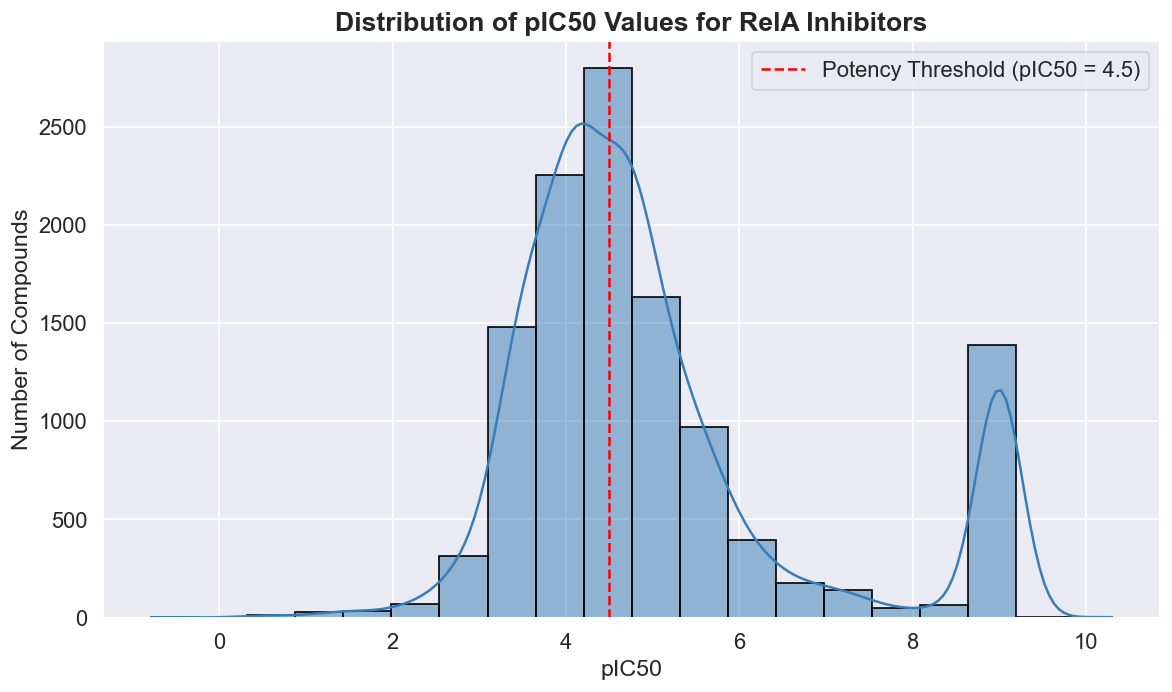

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the best style for publication-quality plots
sns.set_theme(style="darkgrid", font_scale=1.2)

# Create the figure
plt.figure(figsize=(10, 6), dpi=120)  # High DPI for clarity

# Plot histogram with KDE overlay
sns.histplot(df['pIC50'], bins=20, kde=True, color="#377eb8", edgecolor='black')

# Titles and labels
plt.title("Distribution of pIC50 Values for RelA Inhibitors", fontsize=16, weight='bold')
plt.xlabel("pIC50", fontsize=14)
plt.ylabel("Number of Compounds", fontsize=14)

# Optional vertical line for threshold (e.g., pIC50 = 6.0)
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=1.5, label='Potency Threshold (pIC50 = 4.5)')
plt.legend()

# Tight layout
plt.tight_layout()

# Show plot
plt.show()


#### Data Curation based on activity

In [18]:
#  Split the data into active and inactive compounds based on pIC50
active_df = df[df['pIC50'] >= 4.5]
inactive_df = df[df['pIC50'] < 4.5]

# Save the data to separate CSV files
active_output_path = r"C:\Users\DELL\Documents\RelA\active_inhibitors.csv"
inactive_output_path = r"C:\Users\DELL\Documents\RelA\inactive_inhibitors.csv"

active_df.to_csv(active_output_path, index=False)
inactive_df.to_csv(inactive_output_path, index=False)

#  save the file 
print(f"Active inhibitors saved to: {active_output_path}")
print(f"Inactive inhibitors saved to: {inactive_output_path}")

Active inhibitors saved to: C:\Users\DELL\Documents\RelA\active_inhibitors.csv
Inactive inhibitors saved to: C:\Users\DELL\Documents\RelA\inactive_inhibitors.csv


#### Scaffold Extraction from Active Compounds

In [19]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Load the dataset
file_path = r"C:\Users\DELL\Documents\RelA\rela_inhibitors_final.csv"
df = pd.read_csv(file_path)

# Check if 'Smiles' column exists
print("Columns in the dataset:", df.columns)

# Display the first few rows to check for SMILES and other data
print(df.head())

# Function to generate Murcko scaffold for each compound
def get_scaffold(smiles):
    if pd.isna(smiles):  # Check if the SMILES value is NaN
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            return Chem.MolToSmiles(scaffold)
        else:
            return None  # Return None if the molecule could not be parsed
    except Exception as e:
        print(f"Error processing SMILES '{smiles}': {e}")
        return None

# Apply scaffold extraction to all compounds
df['Scaffold'] = df['Smiles'].apply(get_scaffold)

# Check if the 'Scaffold' column was created
print("Columns after adding 'Scaffold':", df.columns)
print(df[['Smiles', 'Scaffold']].head())

Columns in the dataset: Index(['Molecule ChEMBL ID', 'Smiles', 'pIC50'], dtype='object')
  Molecule ChEMBL ID                                             Smiles  \
0      CHEMBL5198863                     CCCCCCCCCCCC(=O)NCCCNCCCCNCCCN   
1      CHEMBL5192058  CCCCCCCCCCCCCC(=O)N1CCC[C@H]1C(=O)N[C@@H](CCCN...   
2      CHEMBL4092269  CC(C)(C)NC(=O)C1(C)COCC(=O)N1/N=C/c1ccc([N+](=...   
3      CHEMBL1814000             CN1c2nccc[n+]2C[C@@]1(O)c1ccccc1.[Br-]   
4      CHEMBL1814366                 CCCCCCCCNc1ncc(-c2cccc(Br)c2)[nH]1   

      pIC50  
0  3.698970  
1  5.207608  
2  4.000000  
3  3.397940  
4  3.096910  
Columns after adding 'Scaffold': Index(['Molecule ChEMBL ID', 'Smiles', 'pIC50', 'Scaffold'], dtype='object')
                                              Smiles  \
0                     CCCCCCCCCCCC(=O)NCCCNCCCCNCCCN   
1  CCCCCCCCCCCCCC(=O)N1CCC[C@H]1C(=O)N[C@@H](CCCN...   
2  CC(C)(C)NC(=O)C1(C)COCC(=O)N1/N=C/c1ccc([N+](=...   
3             CN1c2nccc[n+]2C[C@@]1(O)c1cc

#### Count the occurrences of each scaffold

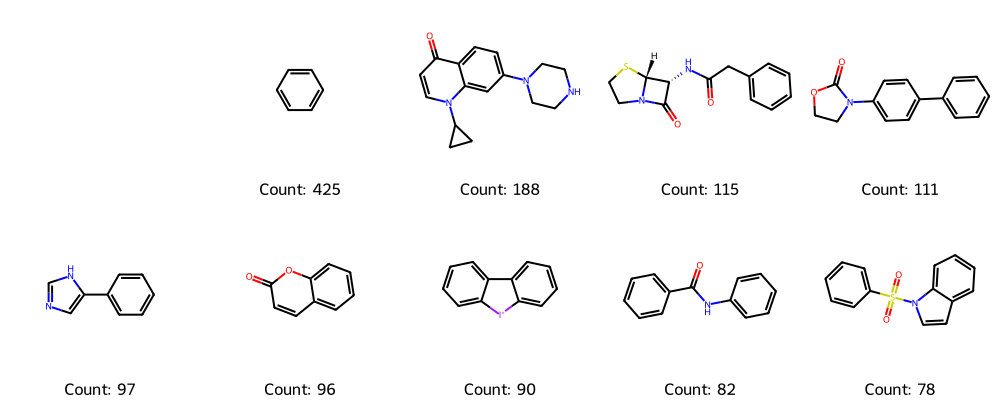

In [20]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# Remove duplicates and NaN values from the scaffold column
scaffolds_cleaned = df['Scaffold'].dropna().drop_duplicates()

# Count and select top 10 scaffolds
top_scaffolds = df['Scaffold'].value_counts().head(10)

# Convert SMILES to Mol objects
scaffold_mols = [Chem.MolFromSmiles(smi) for smi in top_scaffolds.index]

# Create legends with counts
legends = [f"Count: {count}" for count in top_scaffolds.values]

# Draw structures in a grid with legends
img = Draw.MolsToGridImage(scaffold_mols, molsPerRow=5, subImgSize=(200, 200), legends=legends)

# Display inline
display(img)


#### Checking GTP Substructure Similarity

In [21]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd
from IPython.display import display

# Load the dataset
df = pd.read_csv(r"C:\Users\DELL\Documents\RelA\rela_inhibitors_final.csv")

# Define the GTP structure from the provided SMILES
gtp_smiles = "C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O)(O)OP(=O)(O)OP(=O)(O)O)O)O)N=C(NC2=O)N"
gtp_mol = Chem.MolFromSmiles(gtp_smiles)

# Function to extract Murcko scaffold
def get_scaffold(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            return Chem.MolToSmiles(scaffold)
    except:
        return None
    return None

# Generate scaffolds and drop missing values
df['Scaffold'] = df['Smiles'].apply(get_scaffold)
df = df.dropna(subset=['Scaffold'])  # Remove rows with invalid scaffolds

# Count scaffold frequencies
scaffold_counts = df['Scaffold'].value_counts()

# Get top 10 scaffolds and their counts
top_scaffolds = scaffold_counts.head(10)

# Convert SMILES to Mol objects for the top 10 scaffolds
scaffold_mols = [Chem.MolFromSmiles(smi) for smi in top_scaffolds.index]

# Check for GTP substructure match in each scaffold
matching_scaffolds = []
similarity_percentages = []  # To store the similarity percentages

for scaffold_mol in scaffold_mols:
    if scaffold_mol.HasSubstructMatch(gtp_mol):
        matching_scaffolds.append(scaffold_mol)
        # Calculate similarity (based on number of matching atoms)
        match = scaffold_mol.GetSubstructMatch(gtp_mol)
        similarity_percentage = (len(match) / float(len(gtp_mol.GetAtoms()))) * 100
        similarity_percentages.append(similarity_percentage)
    else:
        similarity_percentages.append(0)

# Highlight GTP substructure matches
highlighted_scaffolds = []
for scaffold_mol in matching_scaffolds:
    match = scaffold_mol.GetSubstructMatch(gtp_mol)
    highlighted_scaffolds.append(Draw.MolToImage(scaffold_mol, highlightAtoms=match))

# Display the highlighted scaffold matches
display(*highlighted_scaffolds)

# Optionally, print scaffold counts with GTP match info
print("Top Scaffolds with GTP Substructure Matches:")
for i, scaffold in enumerate(matching_scaffolds):
    print(f"{i+1}. Scaffold SMILES: {Chem.MolToSmiles(scaffold)} | Matches GTP Substructure | Similarity: {similarity_percentages[i]:.2f}%")

# Save the results to a CSV file, ensuring lengths match
matching_scaffolds_smiles = [Chem.MolToSmiles(scaffold) for scaffold in matching_scaffolds]
results_df = pd.DataFrame({
    'Scaffold_SMILES': matching_scaffolds_smiles,
    'Similarity_Percentage': similarity_percentages[:len(matching_scaffolds_smiles)]  # Ensure length match
})
results_df.to_csv(r"C:\Users\DELL\Documents\RelA\matching_scaffolds_with_similarity.csv", index=False)

print("Results saved to 'matching_scaffolds_with_similarity.csv'")


Top Scaffolds with GTP Substructure Matches:
Results saved to 'matching_scaffolds_with_similarity.csv'


#### Fingerprint-Based Similarity Search

1. Similarity: 0.12 | Scaffold SMILES: O=C(Cc1ccccc1)N[C@@H]1C(=O)N2CCS[C@H]12
2. Similarity: 0.11 | Scaffold SMILES: O=c1ccn(C2CC2)c2cc(N3CCNCC3)ccc12
3. Similarity: 0.11 | Scaffold SMILES: O=C1OCCN1c1ccc(-c2ccccc2)cc1
4. Similarity: 0.09 | Scaffold SMILES: O=c1ccc2ccccc2o1
5. Similarity: 0.09 | Scaffold SMILES: O=C(Nc1ccccc1)c1ccccc1
6. Similarity: 0.07 | Scaffold SMILES: O=S(=O)(c1ccccc1)n1ccc2ccccc21
7. Similarity: 0.06 | Scaffold SMILES: c1ccc(-c2cnc[nH]2)cc1
8. Similarity: 0.03 | Scaffold SMILES: c1ccc2c(c1)[I+]c1ccccc1-2
9. Similarity: 0.02 | Scaffold SMILES: c1ccccc1
10. Similarity: 0.00 | Scaffold SMILES: 


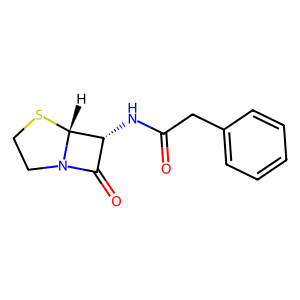

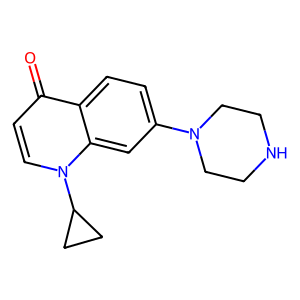

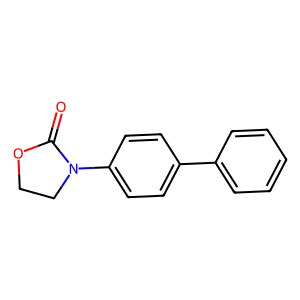

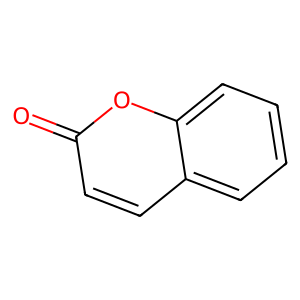

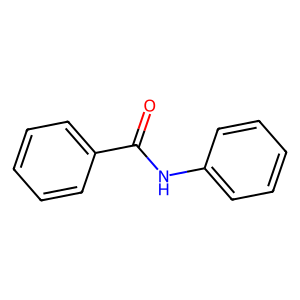

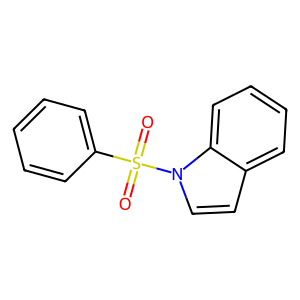

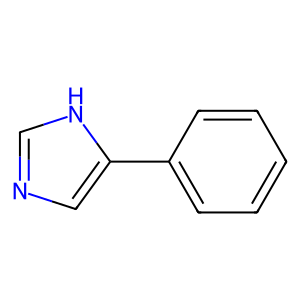

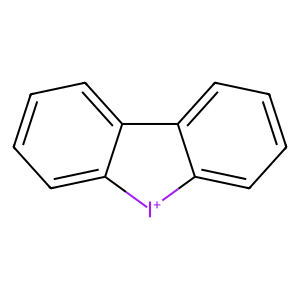

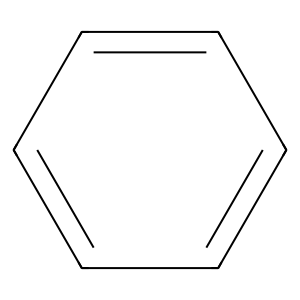

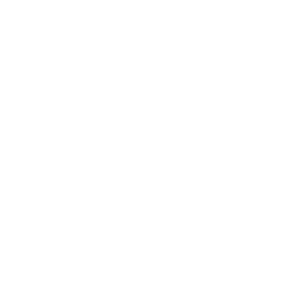

Top similar scaffolds saved to 'top_similar_scaffolds.csv'


In [22]:
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
import pandas as pd

# Function to calculate Tanimoto similarity between two molecules
def calculate_similarity(mol1, mol2):
    # Generate fingerprints
    fp1 = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol1, 2, nBits=1024)
    fp2 = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol2, 2, nBits=1024)
    
    # Calculate Tanimoto similarity
    similarity = DataStructs.TanimotoSimilarity(fp1, fp2)
    return similarity

# Load the dataset
df = pd.read_csv(r"C:\Users\DELL\Documents\RelA\rela_inhibitors_final.csv")

# Define the GTP structure from the provided SMILES
gtp_smiles = "C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O)(O)OP(=O)(O)OP(=O)(O)O)O)O)N=C(NC2=O)N"
gtp_mol = Chem.MolFromSmiles(gtp_smiles)

# Generate scaffolds and drop missing values
df['Scaffold'] = df['Smiles'].apply(get_scaffold)
df = df.dropna(subset=['Scaffold'])  # Remove rows with invalid scaffolds

# Get the top 10 scaffolds and convert SMILES to Mol objects
scaffold_counts = df['Scaffold'].value_counts()
top_scaffolds = scaffold_counts.head(10)
scaffold_mols = [Chem.MolFromSmiles(smi) for smi in top_scaffolds.index]

# Calculate similarity between GTP and each scaffold
similarity_scores = []
for scaffold_mol in scaffold_mols:
    similarity = calculate_similarity(scaffold_mol, gtp_mol)
    similarity_scores.append(similarity)

# Combine similarity scores and scaffold molecules in a list of tuples
scaffolds_with_similarity = list(zip(similarity_scores, scaffold_mols))

# Sort by similarity score (descending order)
sorted_scaffolds = sorted(scaffolds_with_similarity, key=lambda x: x[0], reverse=True)

# Display the top 10 most similar scaffolds
top_similar_scaffolds = sorted_scaffolds[:10]
for i, (score, scaffold_mol) in enumerate(top_similar_scaffolds):
    print(f"{i+1}. Similarity: {score:.2f} | Scaffold SMILES: {Chem.MolToSmiles(scaffold_mol)}")

# Highlight the top similar scaffolds
highlighted_scaffolds = []
for score, scaffold_mol in top_similar_scaffolds:
    highlighted_scaffolds.append(Draw.MolToImage(scaffold_mol))

# Display the highlighted scaffolds
display(*highlighted_scaffolds)

# Save the results to a CSV file with similarity scores
top_similar_scaffolds_smiles = [Chem.MolToSmiles(scaffold) for _, scaffold in top_similar_scaffolds]
results_df = pd.DataFrame({
    'Scaffold_SMILES': top_similar_scaffolds_smiles,
    'Similarity_Score': [score for score, _ in top_similar_scaffolds]
})
results_df.to_csv(r"C:\Users\DELL\Documents\RelA\top_similar_scaffolds.csv", index=False)

print("Top similar scaffolds saved to 'top_similar_scaffolds.csv'")

#### Model generation using the active and inactive datasets

In [23]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Load the active and inactive datasets
active_df = pd.read_csv(r"C:\Users\DELL\Documents\RelA\active_inhibitors.csv")
inactive_df = pd.read_csv(r"C:\Users\DELL\Documents\RelA\inactive_inhibitors.csv")

# Add a label column (1 for active, 0 for inactive)
active_df['Label'] = 1
inactive_df['Label'] = 0

# Combine the datasets
df = pd.concat([active_df, inactive_df], ignore_index=True)

# Function to convert SMILES to Morgan fingerprints (can be adjusted based on the type of feature you need)
def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
        return np.array(fp)
    else:
        return None

# Convert SMILES to fingerprints
df['Fingerprint'] = df['Smiles'].apply(smiles_to_fingerprint)

# Remove any rows with invalid fingerprints
df = df.dropna(subset=['Fingerprint'])

# Prepare features (fingerprints) and target (Label)
X = np.array(list(df['Fingerprint']))
y = df['Label'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Save the model for later use
import joblib
joblib.dump(model, 'pseudomonas_inhibitor_model.pkl')

              precision    recall  f1-score   support

           0       0.80      0.77      0.78      1097
           1       0.81      0.83      0.82      1265

    accuracy                           0.80      2362
   macro avg       0.80      0.80      0.80      2362
weighted avg       0.80      0.80      0.80      2362



['pseudomonas_inhibitor_model.pkl']

#### Concatenating active and inactive datasets

In [24]:
import pandas as pd

# Load both datasets
inactive_df = pd.read_csv(r"C:\Users\DELL\Documents\RelA\inactive_inhibitors.csv")
active_df = pd.read_csv(r"C:\Users\DELL\Documents\RelA\active_inhibitors.csv")

# Make sure both have the same columns and label them
inactive_df['Activity Class'] = 0  # Inactive
active_df['Activity Class'] = 1    # Active

# Combine the datasets
combined_df = pd.concat([active_df, inactive_df], ignore_index=True)

# save combined dataset for future use
combined_df.to_csv("combined_inhibitors.csv", index=False)

# Confirm it's loaded correctly
print(combined_df['Activity Class'].value_counts())


Activity Class
1    6297
0    5513
Name: count, dtype: int64


 #### Feature Engineering to improve the model’s performance

##### i) Import required libraries and load the dataset

In [25]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#  Load Combined Dataset
data = pd.read_csv("combined_inhibitors.csv")
data = data.dropna(subset=["Smiles"])  # Drop rows without SMILES


##### ii) Calculate the Descriptors

In [26]:
#  Descriptor Calculation
def compute_descriptors(Smiles):
    mol = Chem.MolFromSmiles(Smiles)
    if mol is None:
        return pd.Series([None]*5)
    return pd.Series([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.TPSA(mol)
    ])

desc_names = ["MolWt", "LogP", "HBA", "HBD", "TPSA"]
data[desc_names] = data["Smiles"].apply(compute_descriptors)

# Drop missing or invalid descriptor rows 
data = data.dropna(subset=desc_names)

data.to_csv("combined_inhibitors_with_descriptors.csv", index=False)

##### iii) Calculate the Fingerprints

In [27]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import numpy as np

# Load your data
data = pd.read_csv(r"C:\Users\DELL\Documents\RelA\combined_inhibitors.csv")

# Define descriptor calculation
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol)
    ]

# Define ECFP6 fingerprint calculation
def get_ecfp6(smiles, n_bits=2048):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=3, nBits=n_bits)
        return np.array(fp)
    except:
        return None

# Calculate descriptors
descriptor_matrix = np.array(data["Smiles"].apply(calculate_descriptors).tolist())

# Generate and filter fingerprints
fingerprints = data["Smiles"].apply(get_ecfp6)
valid_indices = fingerprints.notna()
fingerprints = np.stack(fingerprints[valid_indices])

# Filter data
data = data[valid_indices].reset_index(drop=True)
data.to_csv(r"C:\Users\DELL\Documents\RelA\filtered_inhibitors.csv", index=False)


In [28]:
# Combine descriptors and fingerprints
features = np.hstack([descriptor_matrix, fingerprints])

# Labels
y = data["Activity Class"].values

# Scale only descriptors (first 4 columns)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features[:, :4] = scaler.fit_transform(features[:, :4])

##### iv) Data splitting using stratification

In [29]:
print(data.columns.tolist())

['Molecule ChEMBL ID', 'Smiles', 'pIC50', 'Activity Class']


In [30]:
# Stack into 2D array
fingerprint_matrix = np.stack(fingerprints)

# Create column names like: FP_0, FP_1, ..., FP_2047
fp_df = pd.DataFrame(fingerprint_matrix, columns=[f'FP_{i}' for i in range(fingerprint_matrix.shape[1])])

# Combine with original data
data = data.reset_index(drop=True)  # ensure index aligns
data = pd.concat([data, fp_df], axis=1)

In [31]:
print(data.shape)


(11810, 2052)


In [32]:
 # Check for missing values
print(data['Activity Class'].isnull().sum()) 

0


In [33]:
import pandas as pd

# Load the dataset
file_path = "C:/Users/DELL/Documents/RelA/combined_inhibitors_with_descriptors.csv"
data = pd.read_csv(file_path)

# Inspect the shape (rows, columns)
print("Shape of dataset:", data.shape)

# View the first 5 rows
print(data.head())

# Check column names
print("Columns:\n", data.columns)

# Check for nulls in key columns
print("\nMissing values per column:\n", data.isnull().sum())

# Check the distribution of 'Activity Class'
print("\nActivity Class distribution:\n", data['Activity Class'].value_counts())


Shape of dataset: (11810, 9)
  Molecule ChEMBL ID                                             Smiles  \
0      CHEMBL5192058  CCCCCCCCCCCCCC(=O)N1CCC[C@H]1C(=O)N[C@@H](CCCN...   
1      CHEMBL1811944                  CCCNc1ncc(-c2ccc(Cl)c(Cl)c2)[nH]1   
2      CHEMBL1083323              CN(C(=O)C1(c2ccc(Cl)cc2)CCC1)c1ccccc1   
3       CHEMBL231616                              NC(=S)N/N=C/c1ncccc1N   
4      CHEMBL3545330                   c1cnc(NCc2ccc(CNc3ncccn3)cc2)nc1   

      pIC50  Activity Class     MolWt     LogP   HBA   HBD    TPSA  
0  5.207608               1  1269.742  0.71021  14.0  16.0  433.42  
1  4.557520               1   270.163  4.20540   2.0   2.0   40.71  
2  4.698970               1   299.801  4.42470   1.0   0.0   20.31  
3  4.698970               1   195.251 -0.16910   4.0   3.0   89.32  
4  4.698970               1   292.346  2.49080   6.0   2.0   75.62  
Columns:
 Index(['Molecule ChEMBL ID', 'Smiles', 'pIC50', 'Activity Class', 'MolWt',
       'LogP', 'HBA',

In [34]:
from sklearn.model_selection import train_test_split

# Assign features and target
X = data.drop(columns=['Activity Class'])  # or select descriptor columns only
y = data['Activity Class']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Confirm class distribution
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())


Train class distribution:
 Activity Class
1    5038
0    4410
Name: count, dtype: int64
Test class distribution:
 Activity Class
1    1259
0    1103
Name: count, dtype: int64


##### v) Model building

In [35]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import joblib

# Step 2: Load your data (ensure 'data' DataFrame already loaded)
# data = pd.read_csv('your_data.csv')

# Ensure the data has columns like 'MolWt', 'LogP', 'HBA', 'HBD', 'TPSA', and 'Activity Class'

# Step 3: Select numerical descriptor features and target
features = ['MolWt', 'LogP', 'HBA', 'HBD', 'TPSA']  
X = data[features]  # Independent variables
y = data['Activity Class']  # Dependent variable

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Step 5: Feature scaling (Standardize the features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform on the training data
X_test_scaled = scaler.transform(X_test)  # Only transform the test data

# Step 6: Train the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust the parameters here
clf.fit(X_train_scaled, y_train)

# Step 7: Make predictions on the test data
y_pred = clf.predict(X_test_scaled)  # Predicted classes
y_prob = clf.predict_proba(X_test_scaled)[:, 1]  # Predicted probabilities for the positive class

# Step 8: Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

# Step 9: Save the trained model and scaler to files for future use
joblib.dump(clf, 'pseudomonas_inhibitor_RF_FEmodel.pkl')  # Save the model
joblib.dump(scaler, 'scaler.pkl')  # Save the scaler (optional, but useful for future scaling)

print("\nModel and scaler saved successfully!")


Confusion Matrix:
 [[805 298]
 [305 954]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73      1103
           1       0.76      0.76      0.76      1259

    accuracy                           0.74      2362
   macro avg       0.74      0.74      0.74      2362
weighted avg       0.74      0.74      0.74      2362

ROC AUC Score: 0.8348244408166912

Model and scaler saved successfully!


##### Vi)  Feature Importance (Random Forest built-in)

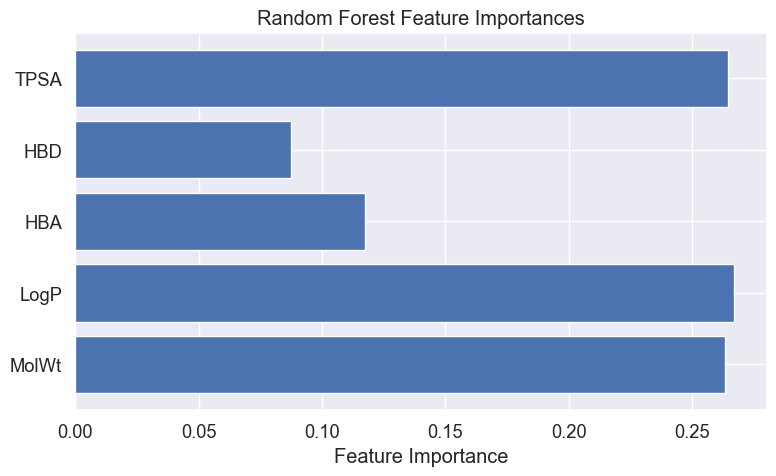

In [36]:
import matplotlib.pyplot as plt

importances = clf.feature_importances_
feature_names = features

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

#### Random Forest Hyperparameter Tuning

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best ROC AUC Score on CV:", grid_search.best_score_)

# Evaluate on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best ROC AUC Score on CV: 0.8338545304078663
Confusion Matrix:
 [[801 302]
 [300 959]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73      1103
           1       0.76      0.76      0.76      1259

    accuracy                           0.75      2362
   macro avg       0.74      0.74      0.74      2362
weighted avg       0.75      0.75      0.75      2362

ROC AUC Score: 0.8382359612782526


#### Plot the ROC curve

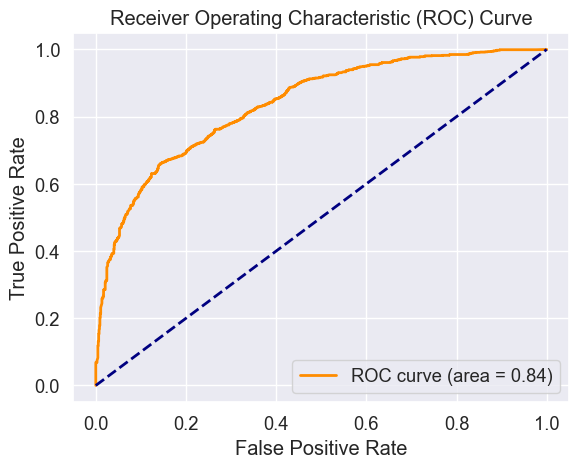

In [38]:
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

# Define and train your model if not already done
model = RandomForestClassifier(bootstrap=False, max_depth=20, min_samples_leaf=1, 
                               min_samples_split=5, n_estimators=300)
model.fit(X_train, y_train)  # Assuming X_train and y_train are your training data

# Then, proceed to plot the ROC curve
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

#### Cross-validation using multiple classifiers

Random Forest: Mean ROC AUC = 0.8286 ± 0.0109
Logistic Regression: Mean ROC AUC = 0.5522 ± 0.0144
SVM (RBF Kernel): Mean ROC AUC = 0.6258 ± 0.0165
Naive Bayes: Mean ROC AUC = 0.5506 ± 0.0058
Decision Tree: Mean ROC AUC = 0.7366 ± 0.0112


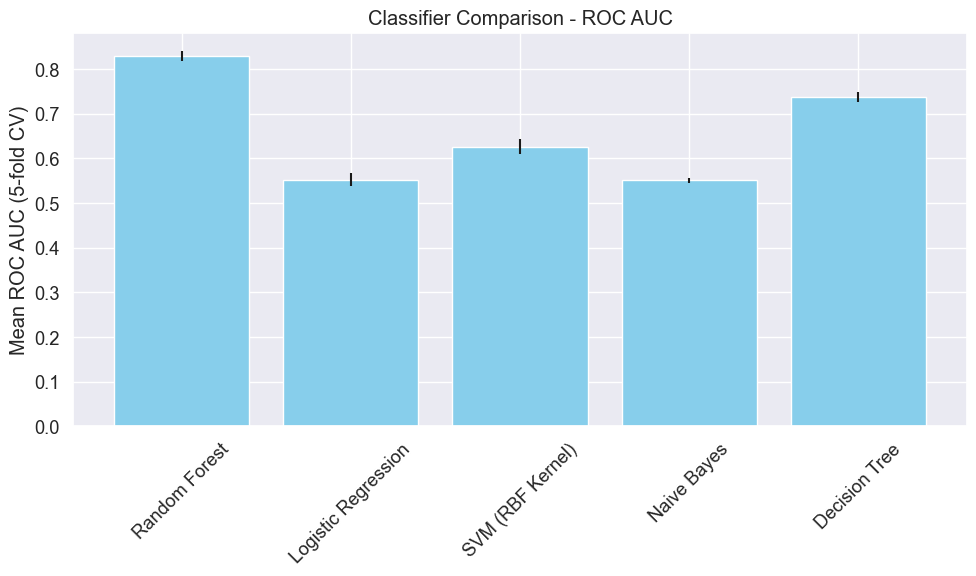

In [39]:
# Step 1: Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load your data (you should already have this)
# data = pd.read_csv('your_data.csv')  # Uncomment if needed

# Step 3: Select features and target
features = ['MolWt', 'LogP', 'HBA', 'HBD', 'TPSA']
X = data[features]
y = data['Activity Class']

# Step 4: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Define classifiers to compare
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM (RBF Kernel)': SVC(probability=True),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Step 6: Perform 5-fold cross-validation and calculate ROC AUC
results = {}
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_scaled, y, cv=5, scoring='roc_auc')
    results[name] = scores
    print(f"{name}: Mean ROC AUC = {scores.mean():.4f} ± {scores.std():.4f}")

# Step 7: Plot ROC AUC scores
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [np.mean(v) for v in results.values()], yerr=[np.std(v) for v in results.values()], color='skyblue')
plt.ylabel('Mean ROC AUC (5-fold CV)')
plt.title('Classifier Comparison - ROC AUC')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Evaluate All Models (including Logistic Regression, Naive Bayes, SVM, and Decision Tree)

#####  i) ROC and AUC Evaluation for All Models

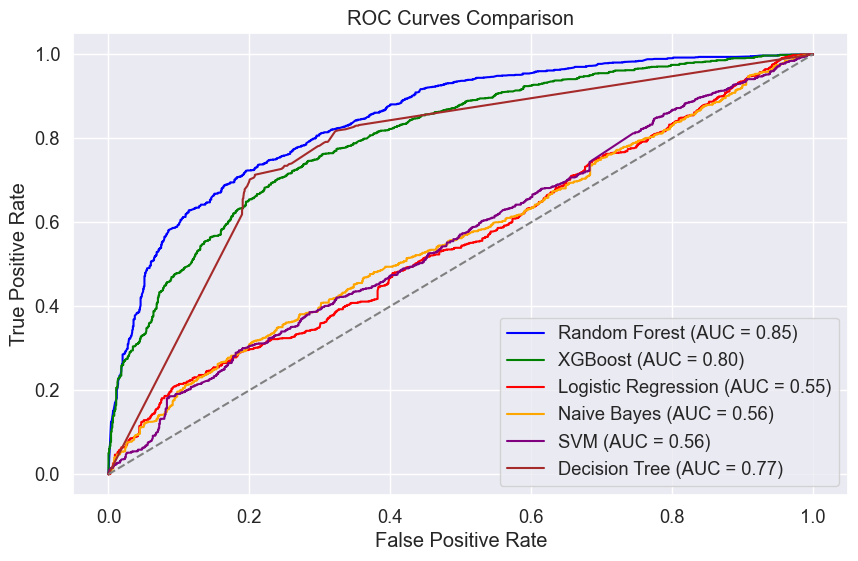

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

# Assuming X and y are your features and target variable (as DataFrames)
# X = your feature data
# y = your target data

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train models
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Convert X_test to DataFrame to ensure feature names are used
X_test = pd.DataFrame(X_test, columns=X_train.columns)

# Get predictions (probabilities) for each model
rf_preds = rf_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict_proba(X_test)[:, 1]
logreg_preds = logreg_model.predict_proba(X_test)[:, 1]
nb_preds = nb_model.predict_proba(X_test)[:, 1]
svm_preds = svm_model.predict_proba(X_test)[:, 1]
dt_preds = dt_model.predict_proba(X_test)[:, 1]

# Calculate ROC curves and AUC scores for each model
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_preds)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_preds)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg_preds)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_preds)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_preds)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_preds)

# Plot ROC curves for all models
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')
plt.plot(fpr_logreg, tpr_logreg, color='red', label=f'Logistic Regression (AUC = {auc(fpr_logreg, tpr_logreg):.2f})')
plt.plot(fpr_nb, tpr_nb, color='orange', label=f'Naive Bayes (AUC = {auc(fpr_nb, tpr_nb):.2f})')
plt.plot(fpr_svm, tpr_svm, color='purple', label=f'SVM (AUC = {auc(fpr_svm, tpr_svm):.2f})')
plt.plot(fpr_dt, tpr_dt, color='brown', label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.2f})')

# Plotting details
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random model (no predictive power)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()


#### Tuned Random Forest — Full Pipeline

📊 Confusion Matrix:
 [[801 302]
 [299 960]]

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73      1103
           1       0.76      0.76      0.76      1259

    accuracy                           0.75      2362
   macro avg       0.74      0.74      0.74      2362
weighted avg       0.75      0.75      0.75      2362

🔥 ROC AUC Score: 0.8382309205092329


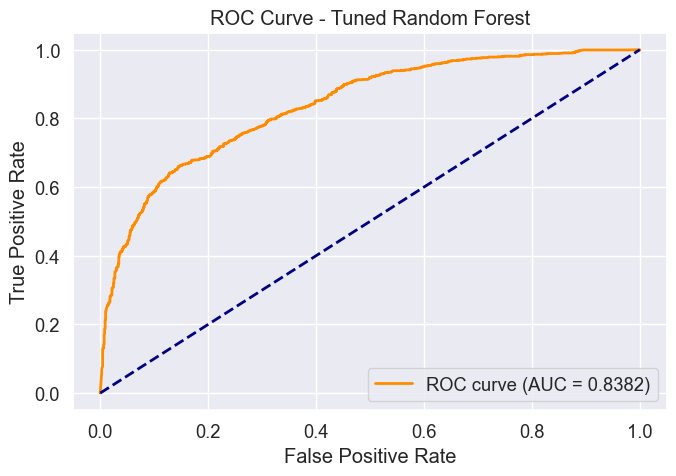

🎯 Stratified K-Fold ROC AUC Scores: [0.84898597 0.85545653 0.84235535 0.8519753  0.84762439]
Mean ROC AUC: 0.8492795081177966
Standard Deviation: 0.0043861693408495765
✅ Model and scaler saved successfully!


In [41]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import joblib

# 📥 Load your data
# data = pd.read_csv("your_data.csv")
features = ['MolWt', 'LogP', 'HBA', 'HBD', 'TPSA']
X = data[features]
y = data['Activity Class']

# 🔀 Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ⚖️ Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)  # For CV

# 🌲 Tuned Random Forest Classifier
tuned_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=False,
    random_state=42
)
tuned_rf.fit(X_train_scaled, y_train)

# ✅ Evaluation on test set
y_pred = tuned_rf.predict(X_test_scaled)
y_prob = tuned_rf.predict_proba(X_test_scaled)[:, 1]

print("📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))
print("🔥 ROC AUC Score:", roc_auc_score(y_test, y_prob))

# 📈 ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔁 Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(tuned_rf, X_scaled, y, cv=skf, scoring='roc_auc')

print("🎯 Stratified K-Fold ROC AUC Scores:", cv_scores)
print("Mean ROC AUC:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

# 💾 Save model and scaler
joblib.dump(tuned_rf, 'tuned_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Model and scaler saved successfully!")


#### XGBoost Training & Evaluation

🎯 XGBoost Stratified K-Fold ROC AUC Scores: [0.81469622 0.82737699 0.79840272 0.82026958 0.81540128]
Mean ROC AUC: 0.8152293593823041
Standard Deviation: 0.00955424750108524

📊 Confusion Matrix (XGBoost):
[[785 318]
 [319 940]]

📄 Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.71      0.71      0.71      1103
           1       0.75      0.75      0.75      1259

    accuracy                           0.73      2362
   macro avg       0.73      0.73      0.73      2362
weighted avg       0.73      0.73      0.73      2362

🔥 ROC AUC Score (XGBoost): 0.809705568681558


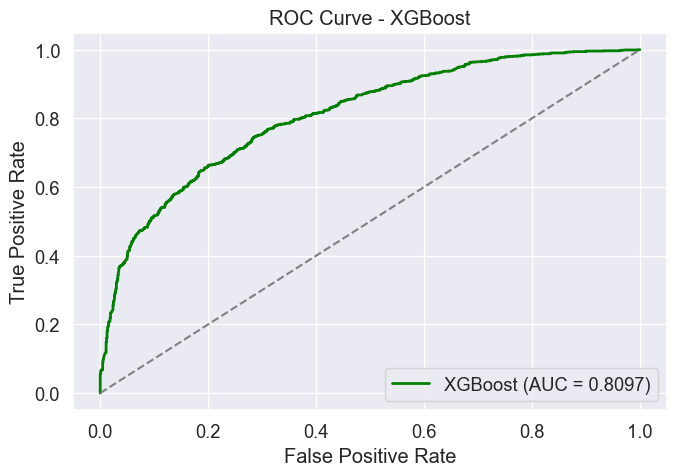

✅ XGBoost model saved as xgboost_model.pkl


In [42]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import joblib

# 📦 XGBoost Classifier with tuned parameters
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# 🔁 Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv_scores = cross_val_score(xgb_clf, X_scaled, y, cv=skf, scoring='roc_auc')

print("🎯 XGBoost Stratified K-Fold ROC AUC Scores:", xgb_cv_scores)
print("Mean ROC AUC:", np.mean(xgb_cv_scores))
print("Standard Deviation:", np.std(xgb_cv_scores))

# ✅ Train and evaluate on test set
xgb_clf.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_clf.predict(X_test_scaled)
y_prob_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Confusion Matrix (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n📄 Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))
print("🔥 ROC AUC Score (XGBoost):", roc_auc_score(y_test, y_prob_xgb))

# 📈 Plot ROC Curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='XGBoost (AUC = %0.4f)' % roc_auc_xgb)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 💾 Save XGBoost model
joblib.dump(xgb_clf, 'xgboost_model.pkl')
print("✅ XGBoost model saved as xgboost_model.pkl")


#### Compare both models on the same ROC plot to visually evaluate performance

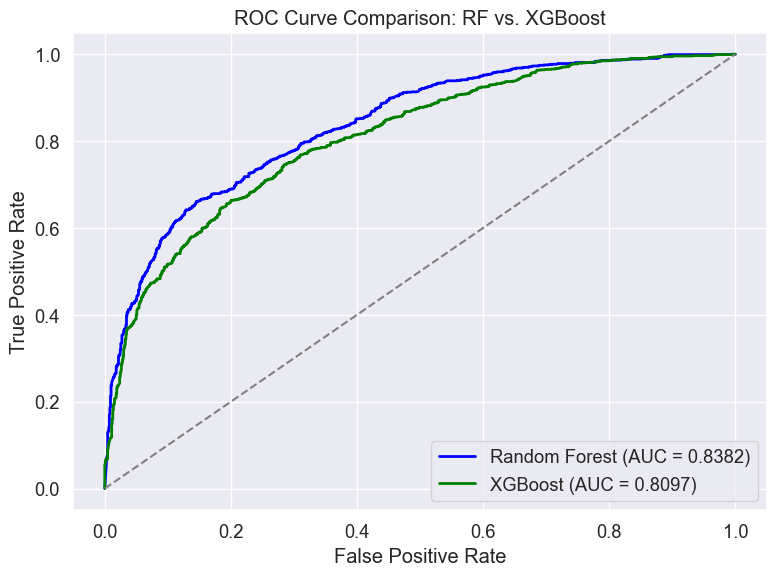

In [43]:
# Re-plot ROC curves of both RF and XGBoost for direct comparison
import joblib
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Load the pre-trained models using joblib
rf_model = joblib.load(r"C:\Users\DELL\Documents\RelA\tuned_rf_model.pkl")
xgb_model = joblib.load(r"C:\Users\DELL\Documents\RelA\xgboost_model.pkl")

# Predict probabilities
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plotting both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label='Random Forest (AUC = %0.4f)' % roc_auc_rf)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='XGBoost (AUC = %0.4f)' % roc_auc_xgb)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('ROC Curve Comparison: RF vs. XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

 #### Comparing feature importance between Random Forest and XGBoost

##### i) Feature Importance for Random Forest

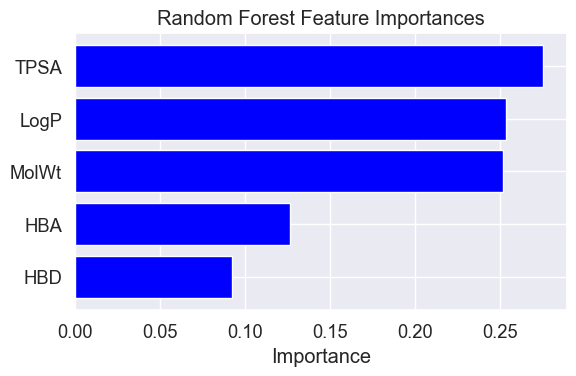

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature names
features = ['MolWt', 'LogP', 'HBA', 'HBD', 'TPSA']

# Get feature importances from trained RF model
rf_importances = rf_model.feature_importances_

# Create a DataFrame
rf_df = pd.DataFrame({'Feature': features, 'Importance': rf_importances})
rf_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(6, 4))
plt.barh(rf_df['Feature'], rf_df['Importance'], color='blue')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

##### ii) Feature Importance for XGBoost

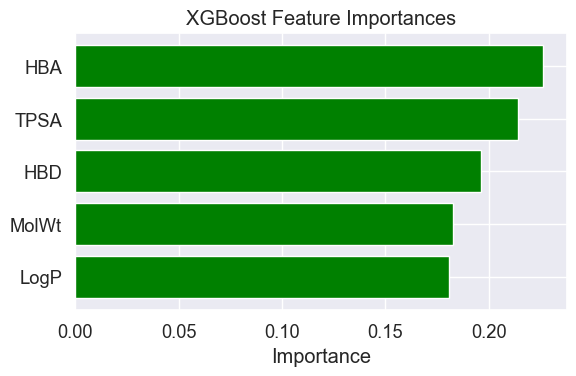

In [45]:
# XGBoost feature importances
xgb_importances = xgb_model.feature_importances_

# Create DataFrame
xgb_df = pd.DataFrame({'Feature': features, 'Importance': xgb_importances})
xgb_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(6, 4))
plt.barh(xgb_df['Feature'], xgb_df['Importance'], color='green')
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

##### Side-by-Side Feature Importance Comparison (RF vs XGBoost)

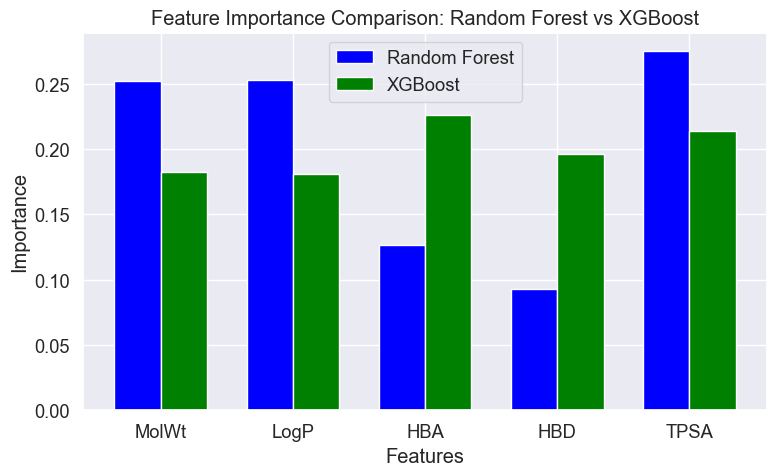

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define your descriptor names and importances
features = ['MolWt', 'LogP', 'HBA', 'HBD', 'TPSA']

# Assuming rf_model and xgb_model are your trained models
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_

# Create a DataFrame for better alignment
comparison_df = pd.DataFrame({
    'Feature': features,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
}).set_index('Feature')

# Plot
bar_width = 0.35
index = np.arange(len(features))

plt.figure(figsize=(8, 5))
plt.bar(index, comparison_df['Random Forest'], bar_width, label='Random Forest', color='blue')
plt.bar(index + bar_width, comparison_df['XGBoost'], bar_width, label='XGBoost', color='green')

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance Comparison: Random Forest vs XGBoost')
plt.xticks(index + bar_width / 2, features)
plt.legend()
plt.tight_layout()
plt.show()


##### Quantify Feature Importance Percentage

In [47]:
import numpy as np
import pandas as pd

# Define your descriptor names and importances
features = ['MolWt', 'LogP', 'HBA', 'HBD', 'TPSA']

# Assuming rf_model and xgb_model are your trained models
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_

# Create a DataFrame for better alignment
comparison_df = pd.DataFrame({
    'Feature': features,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
}).set_index('Feature')

# Calculate the total importance for each model
rf_total_importance = comparison_df['Random Forest'].sum()
xgb_total_importance = comparison_df['XGBoost'].sum()

# Calculate the percentage of importance for each feature
comparison_df['RF Importance (%)'] = (comparison_df['Random Forest'] / rf_total_importance) * 100
comparison_df['XGB Importance (%)'] = (comparison_df['XGBoost'] / xgb_total_importance) * 100

# Print the DataFrame with percentages
print(comparison_df)


         Random Forest   XGBoost  RF Importance (%)  XGB Importance (%)
Feature                                                                
MolWt         0.252016  0.182864          25.201592           18.286409
LogP          0.253355  0.180634          25.335535           18.063427
HBA           0.126551  0.226415          12.655071           22.641453
HBD           0.092514  0.196062           9.251412           19.606247
TPSA          0.275564  0.214025          27.556389           21.402464


In [48]:
print(list(X_train.columns))

['MolWt', 'LogP', 'HBA', 'HBD', 'TPSA']


In [49]:
comparison_df = pd.DataFrame({
    'Feature': features,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
}).set_index('Feature')


#### Screening of VITAS compound Library

##### i) Import necessary libraries

In [50]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

##### ii) Define your CSV file paths

In [51]:
# Replace with the actual CSV files containing SMILES and compound IDs
csv_files = [
    r"C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART1_CSV\STK_Vitas_2024_11_PART1_CSV.csv",
    r"C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART2_CSV\STK_Vitas_2024_11_PART2_CSV.csv",
    r"C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART3_CSV\STK_Vitas_2024_11_PART3_CSV.csv",
    r"C:\Users\DELL\Documents\RelA\STK_Vitas_Update_2024_05_CSV\STK_Vitas_Update_2024_05_CSV.csv",
    r"C:\Users\DELL\Documents\RelA\BBL_Vitas_2024_08\BBL_Vitas_2024_08.csv"
    ]

##### iii) Load and preview each file

In [52]:
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

file_paths = [
    r"C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART1_CSV\STK_Vitas_2024_11_PART1_CSV.csv",
    r"C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART2_CSV\STK_Vitas_2024_11_PART2_CSV.csv",
    r"C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART3_CSV\STK_Vitas_2024_11_PART3_CSV.csv",
    r"C:\Users\DELL\Documents\RelA\STK_Vitas_Update_2024_05_CSV\STK_Vitas_Update_2024_05_CSV.csv",
    r"C:\Users\DELL\Documents\RelA\BBL_Vitas_2024_08\BBL_Vitas_2024_08.csv"
]

all_data = []

for path in file_paths:
    try:
        df = pd.read_csv(path, encoding='utf-8', on_bad_lines='skip', low_memory=False)
        print(f"✅ Loaded (utf-8): {path} → {df.shape[0]} rows")
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(path, encoding='ISO-8859-1', on_bad_lines='skip', low_memory=False)
            print(f"✅ Loaded (ISO-8859-1): {path} → {df.shape[0]} rows")
        except Exception as e:
            print(f"❌ Still failed to load: {path}\n   Error: {e}")
            continue
    except Exception as e:
        print(f"❌ Error loading {path}: {e}")
        continue

    all_data.append(df)

✅ Loaded (utf-8): C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART1_CSV\STK_Vitas_2024_11_PART1_CSV.csv → 474949 rows
✅ Loaded (ISO-8859-1): C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART2_CSV\STK_Vitas_2024_11_PART2_CSV.csv → 453826 rows
✅ Loaded (utf-8): C:\Users\DELL\Documents\RelA\STK_Vitas_2024_11_PART3_CSV\STK_Vitas_2024_11_PART3_CSV.csv → 467494 rows
✅ Loaded (utf-8): C:\Users\DELL\Documents\RelA\STK_Vitas_Update_2024_05_CSV\STK_Vitas_Update_2024_05_CSV.csv → 15417 rows
✅ Loaded (utf-8): C:\Users\DELL\Documents\RelA\BBL_Vitas_2024_08\BBL_Vitas_2024_08.csv → 19123 rows


##### iv) Combine all dataframes

In [53]:
print(f"Number of DataFrames to concatenate: {len(all_data)}")

Number of DataFrames to concatenate: 5


In [54]:
# Check and combine if any files were loaded
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"\n📊 Combined dataset size: {combined_df.shape[0]} rows")

    # Normalize column names
    combined_df.columns = [col.strip().upper() for col in combined_df.columns]


📊 Combined dataset size: 1430809 rows


##### v) Check for missing values

In [55]:
combined_df.isnull().sum()

SUPPLIER               1
ID                   440
CHEMICAL NAME       2214
SMILES           1020329
CAS              1232249
                  ...   
MFCD             1416704
PACK SIZE        1420170
PRICE            1420173
UNNAMED: 10      1420170
UNNAMED: 11      1420170
Length: 64, dtype: int64

###### a) Drop irrelevant columns

In [56]:
# Define specific columns to drop
columns_to_drop = ['SUPPLIER', 'MFCD', 'PACK SIZE', 'PRICE', 'INCHI', 'INCHIKEY', 'MOL. FORMULA', 'MW', 'AVAILABILITY STATUS', 'LEAD TIME', 'UNSPSC CODE', 'HTS CODE', 'SALTDATA', 'MOLECULE URL']

# Add all unnamed columns dynamically
unnamed_cols = [col for col in combined_df.columns if col.upper().startswith('UNNAMED')]
columns_to_drop.extend(unnamed_cols)

# Drop the columns
combined_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print(f"✅ Dropped columns: {columns_to_drop}")
# Define the output path
output_path = r"C:\Users\DELL\Documents\RelA\Vitas_Merged_Cleaned.csv"

# Save to CSV
combined_df.to_csv(output_path, index=False)

print(f"📁 File saved successfully to: {output_path}")


✅ Dropped columns: ['SUPPLIER', 'MFCD', 'PACK SIZE', 'PRICE', 'INCHI', 'INCHIKEY', 'MOL. FORMULA', 'MW', 'AVAILABILITY STATUS', 'LEAD TIME', 'UNSPSC CODE', 'HTS CODE', 'SALTDATA', 'MOLECULE URL', 'UNNAMED: 15', 'UNNAMED: 16', 'UNNAMED: 17', 'UNNAMED: 18', 'UNNAMED: 19', 'UNNAMED: 20', 'UNNAMED: 21', 'UNNAMED: 22', 'UNNAMED: 23', 'UNNAMED: 24', 'UNNAMED: 25', 'UNNAMED: 26', 'UNNAMED: 27', 'UNNAMED: 28', 'UNNAMED: 29', 'UNNAMED: 30', 'UNNAMED: 31', 'UNNAMED: 32', 'UNNAMED: 33', 'UNNAMED: 34', 'UNNAMED: 35', 'UNNAMED: 36', 'UNNAMED: 37', 'UNNAMED: 38', 'UNNAMED: 39', 'UNNAMED: 40', 'UNNAMED: 41', 'UNNAMED: 42', 'UNNAMED: 43', 'UNNAMED: 44', 'UNNAMED: 45', 'UNNAMED: 46', 'UNNAMED: 47', 'UNNAMED: 48', 'UNNAMED: 49', 'UNNAMED: 50', 'UNNAMED: 51', 'UNNAMED: 52', 'UNNAMED: 53', 'UNNAMED: 54', 'UNNAMED: 55', 'UNNAMED: 12', 'UNNAMED: 13', 'UNNAMED: 14', 'UNNAMED: 10', 'UNNAMED: 11']
📁 File saved successfully to: C:\Users\DELL\Documents\RelA\Vitas_Merged_Cleaned.csv


###### b) Drop all rows where SMILES is missing

In [57]:
import pandas as pd

# Load the merged cleaned file
input_path = r"C:\Users\DELL\Documents\RelA\Vitas_Merged_Cleaned.csv"
df = pd.read_csv(input_path)

# Drop rows with missing SMILES
df_cleaned = df.dropna(subset=['SMILES'])
df = pd.read_csv(input_path, dtype={'COLUMN_NAME': str})
# Confirm how many remain
print(f"✅ Remaining rows after dropping missing SMILES: {len(df_cleaned)}")

# Save to a new file
output_path = r"C:\Users\DELL\Documents\RelA\Vitas_Merged_Only_With_SMILES.csv"
df_cleaned.to_csv(output_path, index=False)
print(f"📁 Cleaned file saved to: {output_path}")


✅ Remaining rows after dropping missing SMILES: 410480
📁 Cleaned file saved to: C:\Users\DELL\Documents\RelA\Vitas_Merged_Only_With_SMILES.csv


###### c) ReCheck for missing values

In [58]:
import pandas as pd

input_path = r"C:\Users\DELL\Documents\RelA\Vitas_Merged_Only_With_SMILES.csv"
df = pd.read_csv(input_path, low_memory=False)

missing_counts = df.isna().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])  # Only show columns with missing values

Missing values per column:
ID                    3
CHEMICAL NAME      1033
CAS              220309
dtype: int64


##### v) Remove duplicates based on SMILES and ID

In [59]:
# Drop duplicates where both SMILES 
df_dedup = df.drop_duplicates(subset=['SMILES'])

print(f"✅ Rows after deduplication based on SMILES: {len(df_dedup)}")

# Save the cleaned file
output_path = r"C:\Users\DELL\Documents\RelA\Vitas_Merged_Deduplicated.csv"
df_dedup.to_csv(output_path, index=False)
print(f"📁 Saved deduplicated file to: {output_path}")

✅ Rows after deduplication based on SMILES: 399827
📁 Saved deduplicated file to: C:\Users\DELL\Documents\RelA\Vitas_Merged_Deduplicated.csv


In [60]:
print("📋 Column names in deduplicated DataFrame:")
print(df_dedup.columns.tolist())

📋 Column names in deduplicated DataFrame:
['ID', 'CHEMICAL NAME', 'SMILES', 'CAS']


##### vi) Molecule Sanitization 

In [61]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')  # Disable RDKit warnings

# Load your CSV file
df = pd.read_csv(r"C:\Users\DELL\Documents\RelA\Vitas_Merged_Deduplicated.csv")

# Prepare standardizer and uncharger
normalizer = rdMolStandardize.Normalizer()
uncharger = rdMolStandardize.Uncharger()

# Define function to sanitize and standardize SMILES
def sanitize_and_standardize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles, sanitize=False)
        Chem.SanitizeMol(mol)
        mol = normalizer.normalize(mol)
        fragments = Chem.GetMolFrags(mol, asMols=True)
        mol = max(fragments, key=lambda m: m.GetNumAtoms())
        mol = uncharger.uncharge(mol)
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

# Apply function to the SMILES column
df['standardized_smiles'] = df['SMILES'].astype(str).apply(sanitize_and_standardize)

# Count how many failed
num_invalid = df['standardized_smiles'].isna().sum()
print(f"Invalid SMILES: {num_invalid}")

# Optionally drop rows with invalid SMILES
df_clean = df.dropna(subset=['standardized_smiles'])

# Save cleaned data
df_clean.to_csv(r"C:\Users\DELL\Documents\RelA\Vitas_Cleaned_Standardized.csv", index=False)

print("📋 Column names in standardized and cleaned DataFrame:")
print(df_clean.columns.tolist())

Invalid SMILES: 299
📋 Column names in standardized and cleaned DataFrame:
['ID', 'CHEMICAL NAME', 'SMILES', 'CAS', 'standardized_smiles']


##### Vii) Calculate Descriptors of the compounds

In [62]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem

# Load the data
input_path = r"C:\Users\DELL\Documents\RelA\Vitas_Cleaned_Standardized.csv"
df = pd.read_csv(input_path)

# Convert SMILES to RDKit Mol objects
df['Mol'] = df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))

# Drop rows where molecule could not be parsed
df = df[df['Mol'].notnull()].copy()

# Define descriptor functions 
descriptor_funcs = {
    'MolWt': Descriptors.MolWt,
    'LogP': Descriptors.MolLogP,
    'NumHDonors': Descriptors.NumHDonors,
    'NumHAcceptors': Descriptors.NumHAcceptors,
    'TPSA': Descriptors.TPSA,
}

# Calculate descriptors
for name, func in descriptor_funcs.items():
    df[name] = df['Mol'].apply(func)

# Calculate Morgan fingerprints (radius=2, 2048 bits)
def mol_to_morgan_fp(mol, radius=2, nBits=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)

df['MorganFP'] = df['Mol'].apply(lambda m: mol_to_morgan_fp(m))

#  Fingerprint as a numpy array for modeling:
import numpy as np
def fp_to_array(fp):
    arr = np.zeros((1,))
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_array = np.array([fp_to_array(fp) for fp in df['MorganFP']])
#  Fingerprint matrix to use for modeling

# Save descriptors (excluding Mol and fingerprints, or serialize as needed)
df.drop(columns=['Mol', 'MorganFP'], inplace=True)
df.to_csv(r"C:\Users\DELL\Documents\RelA\Vitas_Merged_Descriptors.csv", index=False)

print("✅ Molecular descriptors calculated and saved.")

✅ Molecular descriptors calculated and saved.


In [63]:
# Check column names after descriptor calculation
print("📋 Column names in descriptor DataFrame:")
print(df.columns.tolist())

📋 Column names in descriptor DataFrame:
['ID', 'CHEMICAL NAME', 'SMILES', 'CAS', 'standardized_smiles', 'MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA']


##### Viii) Load Models & Predict

In [67]:
import pandas as pd
import joblib
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Load descriptor data
descriptor_df = pd.read_csv(r"C:\Users\DELL\Documents\RelA\Vitas_Merged_Descriptors.csv")

# Select only the descriptor columns used during model training
descriptor_columns = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA']
descriptor_data = descriptor_df[descriptor_columns]

# Also prepare vitas_df to store predictions (keep all original info)
vitas_df = descriptor_df.copy()

# Load trained models
rf_model = joblib.load(r"C:\Users\DELL\Documents\RelA\tuned_rf_model.pkl")
xgb_model = joblib.load(r"C:\Users\DELL\Documents\RelA\xgboost_model.pkl")

# Make predictions
vitas_df['RF_Probability'] = rf_model.predict_proba(descriptor_data)[:, 1]
vitas_df['RF_Prediction'] = rf_model.predict(descriptor_data)

vitas_df['XGB_Probability'] = xgb_model.predict_proba(descriptor_data)[:, 1]
vitas_df['XGB_Prediction'] = xgb_model.predict(descriptor_data)

# Save predictions
vitas_df.to_csv(r"C:\Users\DELL\Documents\RelA\Vitas_Predicted_Results.csv", index=False)
print("✅ Predictions completed and results saved.")


✅ Predictions completed and results saved.


In [69]:
# Get top N hits with high predicted probability (e.g., top 50 by RF)
top_hits = vitas_df.sort_values(by='RF_Probability', ascending=False).head(50)

# Show ID, Name, SMILES, and prediction columns
top_hits_info = top_hits[['ID', 'CHEMICAL NAME', 'SMILES', 'RF_Probability', 'XGB_Probability', 
                          'RF_Prediction', 'XGB_Prediction']]

# Save to CSV
top_hits_info.to_csv("Top50_Vitas_Hits.csv", index=False)

top_hits = vitas_df.sort_values(by='RF_Probability', ascending=False).head(50)

top_hits_info = top_hits[['ID', 'CHEMICAL NAME', 'SMILES', 'RF_Probability', 'XGB_Probability', 
                          'RF_Prediction', 'XGB_Prediction']]

top_hits_info.to_csv("Top50_Vitas_Hits.csv", index=False)

print(top_hits_info.head())

               ID                                      CHEMICAL NAME  \
1151    STK361815                  9-pentofuranosyl-9H-purin-6-amine   
74264   STK391124        4-amino-1-pentofuranosylpyrimidin-2(1H)-one   
382882  STL507277  6-O-[(4-methylphenyl)sulfonyl]-alpha-D-glucopy...   
386368  STL525153  2-(2-chloroethoxy)ethyl 2-(acetylamino)-2-deox...   
234713  STK674106  4-amino-5-bromo-1-pentofuranosylpyrimidin-2(1H...   

                                                   SMILES  RF_Probability  \
1151                        OCC1OC(C(C1O)O)n1cnc2c1ncnc2N          0.8875   
74264                        OCC1OC(C(C1O)O)n1ccc(nc1=O)N          0.8875   
382882  Cc1ccc(cc1)S(=O)(=O)OC[C@H]1O[C@H](O)[C@@H]([C...          0.8875   
386368  ClCCOCCO[C@@H]1O[C@H](CO)[C@H]([C@@H]([C@H]1NC...          0.8875   
234713                   OCC1OC(C(C1O)O)n1cc(Br)c(nc1=O)N          0.8875   

        XGB_Probability  RF_Prediction  XGB_Prediction  
1151           0.962819              1         

#### Filtering Based on Lipinski’s Rule of 5

In [70]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

# Load the hits file
df = pd.read_csv("Top50_Vitas_Hits.csv")

# Convert SMILES to RDKit Mol objects
df['Mol'] = df['SMILES'].apply(Chem.MolFromSmiles)

# Compute drug-likeness descriptors
df['MW'] = df['Mol'].apply(Descriptors.MolWt)
df['LogP'] = df['Mol'].apply(Crippen.MolLogP)
df['HBD'] = df['Mol'].apply(Lipinski.NumHDonors)
df['HBA'] = df['Mol'].apply(Lipinski.NumHAcceptors)
df['TPSA'] = df['Mol'].apply(rdMolDescriptors.CalcTPSA)
df['RotB'] = df['Mol'].apply(Lipinski.NumRotatableBonds)

# Apply Lipinski Rule of Five
df['Lipinski_Pass'] = (
    (df['MW'] <= 500) &
    (df['LogP'] <= 5) &
    (df['HBD'] <= 5) &
    (df['HBA'] <= 10)
)

# Filter and save the hits that pass
filtered_hits = df[df['Lipinski_Pass']]
filtered_hits.to_csv("Lipinski_Filtered_Hits.csv", index=False)

# Show summary
print(f"{len(filtered_hits)} compounds passed Lipinski filtering.")
print(filtered_hits[['ID', 'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotB']].head())


39 compounds passed Lipinski filtering.
          ID       MW     LogP  HBD  HBA    TPSA  RotB
0  STK361815  267.245 -1.98000    4    9  139.54     2
1  STK391124  243.219 -2.56300    4    8  130.83     2
2  STL507277  334.346 -1.49978    4    8  133.52     4
3  STL525153  327.761 -1.79790    4    7  117.48     8
4  STK674106  322.115 -1.80050    4    8  130.83     2


#### PAINS Filtering

In [72]:
from rdkit.Chem import FilterCatalog

# Load PAINS filter
params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A)
catalog = FilterCatalog.FilterCatalog(params)

# Apply PAINS filter
def check_pains(mol):
    if mol is None:
        return "Invalid"
    entry = catalog.GetFirstMatch(mol)
    return entry.GetDescription() if entry else "No PAINS"

# Safely assign the PAINS result using .loc to avoid the warning
filtered_hits.loc[:, 'PAINS_Result'] = filtered_hits['Mol'].apply(check_pains)

# Filter out compounds with PAINS alerts
pains_cleaned = filtered_hits[filtered_hits['PAINS_Result'] == "No PAINS"]

# Save output
pains_cleaned.to_csv("Lipinski_PAINS_Cleaned_Hits.csv", index=False)

print(f"{len(pains_cleaned)} compounds remain after PAINS filtering.")


38 compounds remain after PAINS filtering.


#### Remove Structurally Unstable or Reactive Compounds

In [74]:
from rdkit import Chem

# Define common reactive SMARTS patterns 

reactive_smarts = [
    '[CX3](=O)[OX1H0-,OX2H1]',  # Carboxylic acid derivatives
    '[CX3](=O)[#6]',            # Aldehydes
    'C=CC=O',                   # α,β-unsaturated aldehydes (Michael acceptors)
    '[OX2H][CX3]=O',            # Aldehyde or ketone OH groups
    'C#N',                      # Nitriles (can be reactive)
    '[SX2]([#6])[#6]',          # Thiols and sulfides
    '[NX3][CX3](=O)[OX1]',      # Amides (some reactive)
    'C1=CC=CC=C1[Cl,Br,I]',     # Aromatic halides
    '[N+](=O)[O-]',             # Nitro groups
    '[OX1]=[CX2]',              # Epoxides
    '[C;H2][C;H2][OH]',         # Alcohols on alkyl chains (potentially reactive)
    'C=CC=O',                 # Michael acceptors
    'C(=O)OC(=O)',            # Anhydrides
    '[N+](=O)[O-]',           # Nitro groups
    'N=C=O',                  # Isocyanates
    '[N-]=[N+]=N',            # Azides
    '[N]=[N+]',               # Diazo
    '[SH]',                   # Thiols
    'S-S',                    # Disulfides
    'OO',                     # Peroxides
    '[CX4][Cl,Br,I,F]',       # Halomethyl groups
    'c[Cl,Br,I,F]',           # Aromatic halides
    'C(=O)Cl',                # Acid chlorides
    'S(=O)(=O)Cl',            # Sulfonyl chlorides
    '[NX3]1[C;H2][C;H2]1',    # Aziridines
    'N=C=N',                  # Carbodiimides
    '[CX3]=[NX2]',            # Imines
    '[CX4]N#C',               # Alkyl isocyanides
    'NN',                     # Hydrazines
    'N#C-O',                  # Cyanates
    'O=C1NC=CO1',             # Azlactones
    'C(F)(F)(F)',             # Perfluoroalkyl groups
    'C1=CC(=O)NC(=O)N1',      # Maleimides
    'C1=CC(=O)C=CC1=O'        # Quinones
]

# Compile SMARTS patterns
reactive_patterns = [Chem.MolFromSmarts(s) for s in reactive_smarts]

def has_reactive_group(mol):
    if mol is None:
        return False
    for patt in reactive_patterns:
        if mol.HasSubstructMatch(patt):
            return True
    return False

# Filter out molecules with reactive groups
pains_cleaned.loc[:, 'Reactive_Group'] = pains_cleaned['Mol'].apply(has_reactive_group)
stable_compounds = pains_cleaned[~pains_cleaned['Reactive_Group']]

print(f"Removed {pains_cleaned['Reactive_Group'].sum()} reactive/unstable compounds.")
print(f"{len(stable_compounds)} stable compounds remain after reactive group filtering.")

# Save filtered dataset
stable_compounds.to_csv("Stable_Cleaned_Hits.csv", index=False)

Removed 17 reactive/unstable compounds.
21 stable compounds remain after reactive group filtering.


#### Visualize 2D Structures of hit molecules

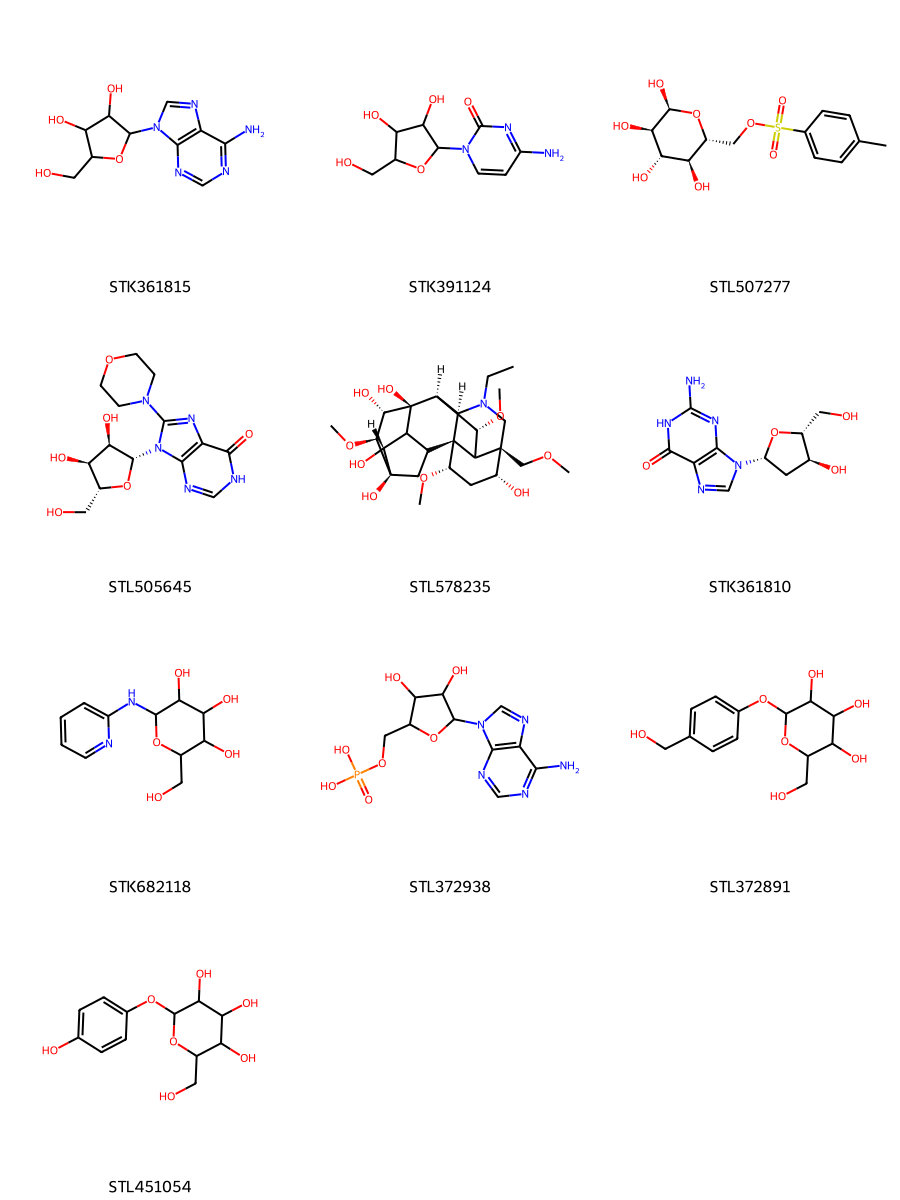

In [79]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# Step 1: Load CSV file
stable_compounds_expanded = pd.read_csv("Stable_Cleaned_Hits.csv")

# Step 2: Convert SMILES to RDKit Mol objects
stable_compounds_expanded['Mol'] = stable_compounds_expanded['SMILES'].apply(Chem.MolFromSmiles)

# Step 3: Visualize first 10 molecules in a grid
img = Draw.MolsToGridImage(
    stable_compounds_expanded['Mol'][:10].tolist(),
    legends=stable_compounds_expanded['ID'][:10].tolist(),
    molsPerRow=3,
    subImgSize=(300, 300)
)
display(img)


#### Generate 3D structures for Docking

In [80]:
from rdkit.Chem import AllChem

def generate_3d(mol):
    mol_h = Chem.AddHs(mol)  # Add hydrogens
    success = AllChem.EmbedMolecule(mol_h)  # Generate 3D coordinates
    if success == 0:
        AllChem.UFFOptimizeMolecule(mol_h)  # Optimize geometry
        return mol_h
    else:
        return None

stable_compounds_expanded['Mol3D'] = stable_compounds_expanded['Mol'].apply(generate_3d)

print(f"3D structures generated: {stable_compounds_expanded['Mol3D'].notnull().sum()}/{len(stable_compounds_expanded)}")

3D structures generated: 20/21


##### Identify the problematic compound and diagnose

In [81]:
# Find rows where 3D embedding returned None
failed_idx = stable_compounds_expanded[stable_compounds_expanded['Mol3D'].isnull()].index

print("Failed to generate 3D for these compounds:")
print(stable_compounds_expanded.loc[failed_idx, ['ID', 'SMILES']])


Failed to generate 3D for these compounds:
          ID                                             SMILES
4  STL578235  COC[C@@]12CN(CC)[C@H]3[C@]4(C2[C@@H](OC)[C@H]3...


 ##### Alternative embedding method 

In [82]:
from rdkit.Chem import AllChem

def generate_3d_with_etkdg(mol):
    mol_h = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = 0xf00d
    params.maxAttempts = 20
    success = AllChem.EmbedMolecule(mol_h, params)
    if success == 0:
        AllChem.UFFOptimizeMolecule(mol_h)
        return mol_h
    else:
        return None

failed_compound = stable_compounds_expanded.loc[4]  # Index of failed compound
mol3d_alt = generate_3d_with_etkdg(failed_compound['Mol'])

if mol3d_alt:
    print("Alternative embedding succeeded!")
else:
    print("Still failed to embed 3D.")


Still failed to embed 3D.


##### Check SMILES Validity

In [83]:
from rdkit import Chem

mol = Chem.MolFromSmiles(failed_compound['SMILES'])
if mol is None:
    print("Invalid SMILES!")
else:
    print("SMILES is valid.")

SMILES is valid.


##### Open Babel for 3D structure generation

In [87]:
from openbabel import pybel

smiles = failed_compound['SMILES']

# Create molecule
mol = pybel.readstring("smi", smiles)

# Generate 3D coords
mol.make3D()

# Save file - first arg is format, second is filename
mol.write("sdf", "failed_compound_3d.sdf", overwrite=True)

print("3D structure saved as failed_compound_3d.sdf")


3D structure saved as failed_compound_3d.sdf
